# Submission Proyek Analisis Data
# Dataset: Air Quality Dataset

## Persiapan
Memanggil seluruh library yang dibutuhkan untuk menyelesaikan Notebook ini (fungsi dan kegunaan akan dicantumkan di `requirements.txt`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import folium 

## 1. Menentukan Pertanyaan Bisnis

### 1.1 Latar Belakang

Polusi udara merupakan salah satu isu lingkungan utama di wilayah urban. Dataset ini berisi data kualitas udara dari beberapa stasiun pemantauan selama periode tahun 2013–2017.

### 1.2 Mendefinisikan Pertanyaan

### Pertanyaan ke-1: Bagaimana tren rata-rata PM2.5 per bulan selama periode 2013–2017?
- Specific: Fokus pada PM2.5 sebagai indikator kualitas udara
- Measurable: Diukur menggunakan rata-rata PM2.5 per bulan
- Action-oriented: Membantu menentukan periode dengan polusi tinggi untuk penanganan musiman
- Relevant: PM2.5 merupakan indikator utama pencemaran udara yang berdampak pada kesehatan
- Time-bound: Periode yang dipertanyakan mulai dari tahun 2013 sampai tahun 2017

### Pertanyaan ke-2: Stasiun pemantauan mana yang memiliki rata-rata PM2.5 tertinggi selama periode 2013–2017?
- Specific: Fokus pada identifikasi stasiun dengan rata-rata PM2.5 tertinggi
- Measurable: Diukur menggunakan rata-rata PM2.5 tiap stasiun
- Action-oriented: Membantu menentukan wilayah prioritas mitigasi polusi
- Relevant: Identifikasi hotspot penting untuk pengambilan keputusan penanggulangan polusi
- Time-bound: Periode yang dipertanyakan mulai dari tahun 2013 sampai tahun 2017

### 1.3 Mengapa PM2.5?

Berdasarkan pemahaman yang saya sudah lakukan, tingkat PM2.5 (Particulate Matter 2.5) adalah ukuran terkecil dari partikel polusi yang mana hal ini tentunya mendukung PM2.5 menjadi parameter penting mengenai tingkat polusi yang terjadi selama periode 2013-2017 karena satuannya yang kecil yang menghasilkan angka akurat terhadap level kualitas udara

## 2. Data Wrangling

### 2.1 Gathering Data

Menggabungkan seluruh file CSV menjadi satu DataFrame. Tahapan ini penting agar memudahkan proses visualisasi dan analisis, terlebih lagi dataset yang sudah memiliki format/susunan kolom yang sama satu dengan lainnya.

In [2]:
# mengambil dataset yang berada pada folder data dan dengan format penamaan awal yang sama (PRSA_Data_)
files = glob.glob('data/PRSA_Data_*.csv')

# data disimpan di sebuah list kosong
df_list = []

# perulangan untuk read csvnya dan menggunakan variabel temp dan metode append
for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

# menggabungkan dataset hasil append ke variabel df
df = pd.concat(df_list, ignore_index=True)

# mengecek apakah dataset bisa diload dan berhasil digabungkan
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


Dapat terlihat secara langsung data memiliki format yang mirip dan sudah rapi, namun tidak menutup kemungkinan adanya kejanggalan pada data, maka selanjutnya kita masuk ke proses menilai data.

### 2.2 Assessing Data

Memeriksa struktur data, missing values, dan duplikasi. Setelah dataset berhasil dikumpulkan, langkah pengecekan dataset merupakan bagian penting agar hasil analisis dan visualisasi tidak membingungkan dan tidak menimbulkan kesimpulan yang tidak realistis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


Dari `df.info()`, kita bisa melihat jumlah baris tiap kolom tidak sama rata. Artinya hal ini menandakan terdapatnya missing value pada dataset. Selain itu format tanggal masih terpisah. 

In [4]:
# mengecek missing value tiap kolom
df.isna().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

Terdapat beberapa kolom penting yang memiliki missing value.

In [5]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


Dari `df.describe()`, terdapat kemungkinan outlier yang dapat terlihat dari nilai `max` beberapa kolom. Namun disini saya akan berfokus pada kolom PM2.5 yang merupakan indikator utama yang saya gunakan dalam menjawab pertanyaan bisnis.

In [6]:
Q1 = df['PM2.5'].quantile(0.25) # kuantil bawah (Q1)
Q3 = df['PM2.5'].quantile(0.75) # kuantil atas (Q3)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# variabel yang menampung setiap data yang melewati Q1 atau Q3 (Outliers)
outliers_pm25 = df[
    (df['PM2.5'] < batas_bawah) | 
    (df['PM2.5'] > batas_atas)
]

print("Batas Bawah :", batas_bawah)
print("Batas Atas :", batas_atas)

# menghitung jumlah outlier
print("Jumlah Outlier kolom PM2.5 :", len(outliers_pm25))

Batas Bawah : -116.5
Batas Atas : 247.5
Jumlah Outlier kolom PM2.5 : 19142


Berdasarkan `Batas Atas`, dapat ditentukan bahwa setiap nilai yang berada diatas 247.5 adalah outlier

In [7]:
df.duplicated().sum()

np.int64(0)

Dari `df.duplicated()`, dapat dilihat bahwa tidak ada data duplikat pada dataset 

Masalah yang ditemukan:
1. Missing values pada beberapa kolom.
2. Format tanggal masih terpisah menjadi year, month, day, hour.
3. Terdapat kemungkinan outlier

### 2.3 Cleaning Data

Membersihkan data berdasarkan masalah yang ditemukan. Tahap lanjutan setelah dataset dinilai sebelumnya pada tahap assessing. Hal ini berguna agar dataset siap digunakan untuk analisis dan visualisasi.

Menggabungkan data waktu mulai dari tahun, bulan, hari, dan jam menjadi satu kolom bernama `datetime` agar lebih mudah dibaca dan rapi

In [20]:
# Menggabungkan kolom year, month, day, dan hour menjadi satu kolom bernama datetime
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

Membersihkan data dengan teknik interpolasi dan mengisi kekosongan dengan median jika masih ada missing value

In [ ]:
# Daftar kolom yang akan dibersihkan missing value-nya
numeric_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

# Loop untuk membersihkan missing value pada tiap kolom numerik
for col in numeric_cols:
    
    # Mengisi missing value menggunakan interpolasi yang cocok untuk data time-series karena mempertimbangkan nilai sebelum dan sesudah
    df[col] = df[col].interpolate()
    
    # Jika masih ada missing value di awal/akhir data setelah interpolasi, isi dengan median kolom sebagai fallback
    df[col] = df[col].fillna(df[col].median())

Menghapus baris duplikat jika ada (antisipasi bilamana terlewat saat assessing)

In [ ]:
df.drop_duplicates(inplace=True)

Menghapus outlier ekstrem PM2.5 di atas 300. Threshold dipilih berdasarkan survey batas atas menggunakan IQR

In [ ]:
df = df[df['PM2.5'] <= 300]

# Menampilkan hasil cleaning (mengecek apakah ada kejanggalan lain dari kolom)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


Setelah data selesai di bersihkan, selanjutnya kita dapat melakukan eksplorasi data.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Analisis Tren PM2.5 Bulanan

Mengambil rata-rata kadar PM2.5 bulanan untuk mempermudah analisa dan pengambilan kesimpulan. 

In [9]:
df['month_period'] = df['datetime'].dt.to_period('M') # menambah kolom baru sebagai parameter ukur dalam bentuk format bulanan
monthly_pm25 = df.groupby('month_period')['PM2.5'].mean().reset_index() # menghitung rata rata tiap bulan keseluruhan

monthly_pm25


,month_period,PM2.5
0,2013-03,94.288110
1,2013-04,62.207292
2,2013-05,80.320901
3,2013-06,96.674514
4,2013-07,66.752664
5,2013-08,60.417460
6,2013-09,75.017585
7,2013-10,85.660323
8,2013-11,70.227731
9,2013-12,68.421672


Berdasarkan agregasi rata-rata PM2.5 per bulan, terlihat bahwa tingkat polusi udara mengalami fluktuasi sepanjang periode observasi. Nilai PM2.5 bulanan tidak stabil dari bulan ke bulan, yang mengindikasikan adanya pola musiman pada kualitas udara keseluruhan daerah.

### 3.2 Analisis Tingkat PM2.5 per Stasiun

In [10]:
station_pm25 = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False) # mengambil rata-rata PM2.5 tiap stasiun dan diurutkan secara descending
station_pm25


station
Dongsi           77.021391
Gucheng          75.790709
Wanshouxigong    75.618985
Guanyuan         75.281730
Wanliu           75.229893
Nongzhanguan     74.907513
Tiantan          74.729422
Aotizhongxin     74.539691
Shunyi           71.969244
Changping        66.722801
Huairou          65.331765
Dingling         61.900438
Name: PM2.5, dtype: float64

Berdasarkan rata-rata PM2.5 per stasiun monitoring, stasiun Dongsi tercatat memiliki tingkat PM2.5 rata-rata tertinggi sebesar sekitar 77.02, diikuti oleh Gucheng dan Wanshouxigong. Sebaliknya, Dingling dan Huairou menunjukkan tingkat PM2.5 rata-rata terendah di antara seluruh stasiun.

Temuan ini menunjukkan adanya variasi spasial dalam distribusi polusi udara, di mana beberapa wilayah memiliki tingkat polusi yang cenderung lebih tinggi dibanding wilayah lainnya.

### 3.3 Mengkategorikan Tingkatan PM2.5

In [11]:
def categorize_pollution(pm):
    if pm <= 50:
        return 'Low'
    elif pm <= 150:
        return 'Medium'
    else:
        return 'High'

df['pollution_category'] = df['PM2.5'].apply(categorize_pollution) # membuat kolom baru yang berisi kategori PM2.5

pollution_distribution = df['pollution_category'].value_counts() # variabel untuk menampung hasil pengelompokan

pollution_distribution


pollution_category
Low       198916
Medium    157992
High       53780
Name: count, dtype: int64

Mengelompokkan tingkat PM2.5 yang terjadi pada keseluruhan daerah selama periode 2013-2017. Berdasarkan temuan ini, dapat dilihat tren dari PM2.5 cenderung berada di level rendah dan sedang dan jarang terjadi pencatatan PM2.5 di level tinggi.

## 4. Visualization & Explanatory Analysis

### 4.1 Visualisasi Tren PM2.5 Bulanan

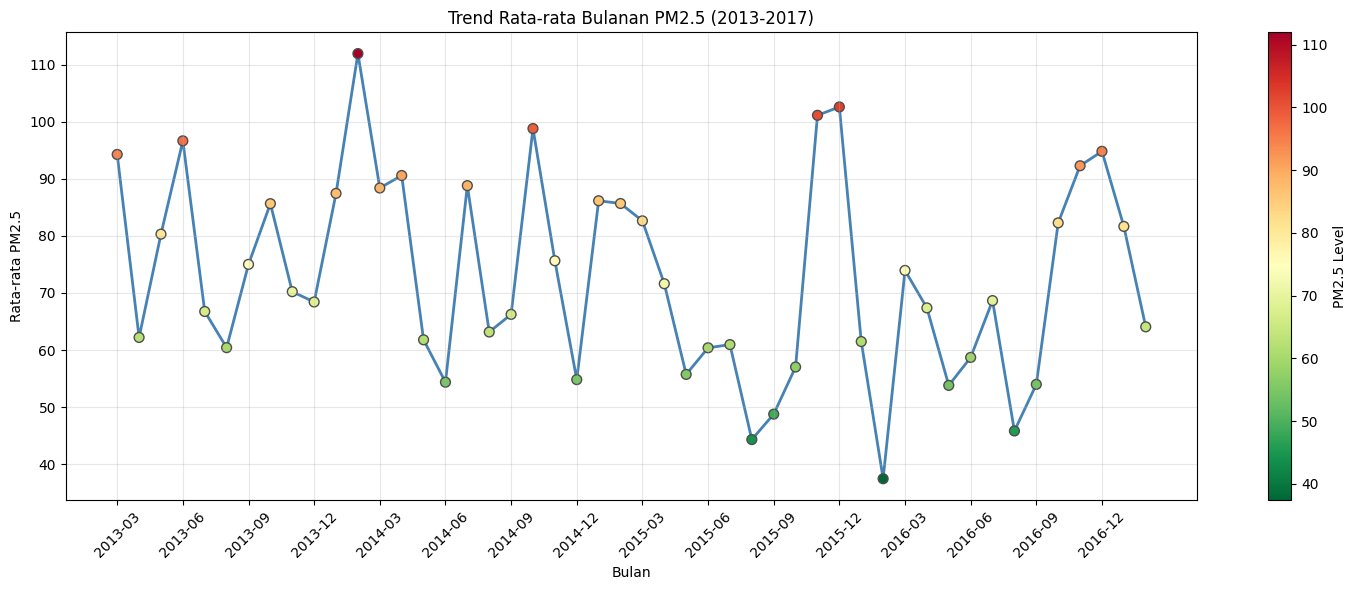

In [12]:
# Container visualisasi
plt.figure(figsize=(15,6))

# Plot line (warna biru)
plt.plot(
    monthly_pm25['month_period'].astype(str),
    monthly_pm25['PM2.5'],
    linewidth=2,
    color='steelblue',
    zorder=1
)

# Marker berwarna berdasarkan nilai PM2.5
scatter = plt.scatter(
    monthly_pm25['month_period'].astype(str),
    monthly_pm25['PM2.5'],
    c=monthly_pm25['PM2.5'],
    cmap='RdYlGn_r',   # memilih warna pada mapping yaitu red, yellow, green yang direverse agar red menjadi yang tertinggi karena korelasi berbanding terbalik
    s=50,
    edgecolors="#4D4D4D"
)

# Label X
plt.xticks(
    ticks=range(0, len(monthly_pm25), 3),
    labels=monthly_pm25['month_period'].astype(str)[::3], # label dibagi dengan jarak per tiga bulan agar tidak ramai
    rotation=45 # rotasi 45 derajat
)

plt.title('Trend Rata-rata Bulanan PM2.5 (2013-2017)')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata PM2.5')

# garis bantu
plt.grid(alpha=0.3)

# Legend warna / colorbar
plt.colorbar(scatter, label='PM2.5 Level')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi ini, dapat dilihat tingkat PM2.5 yang tinggi terjadi di sekitar akhir dan awal tahun, seperti di bulan 2 tahun 2014 dan bulan 12 tahun 2015. DIsisi lain, terjadi penurunan setelah penaikan yang drastis seperti pada bulan 1 tahun 2016 sampai bulan 2 tahun 2016. Dari informasi ini, dapat disimpulkan bahwa akan terjadi peningkatan polusi di saat-saat penting seperti tahun baru dan mungkin hari besar lainnya yang dimana akan banyak transportasi pribadi yang beroperasi disaat itu. Selain itu, penurunan tingkat polusi juga terjadi saat sesudah melewati tingkat polusi yang tinggi, hal ini mungkin saja dapat terjadi melalui perilaku masyarakat yang kembali ke aktivitas normalnya seperti menggunakan transportasi umum atau jalan kaki. Tentunya kesimpulan ini hanya sebatas hasil analisa saya dan masih banyak faktor selain faktor transportasi dan hari-hari penting.

### 4.2 Visualisasi Rata-Rata PM2.5 per Stasiun

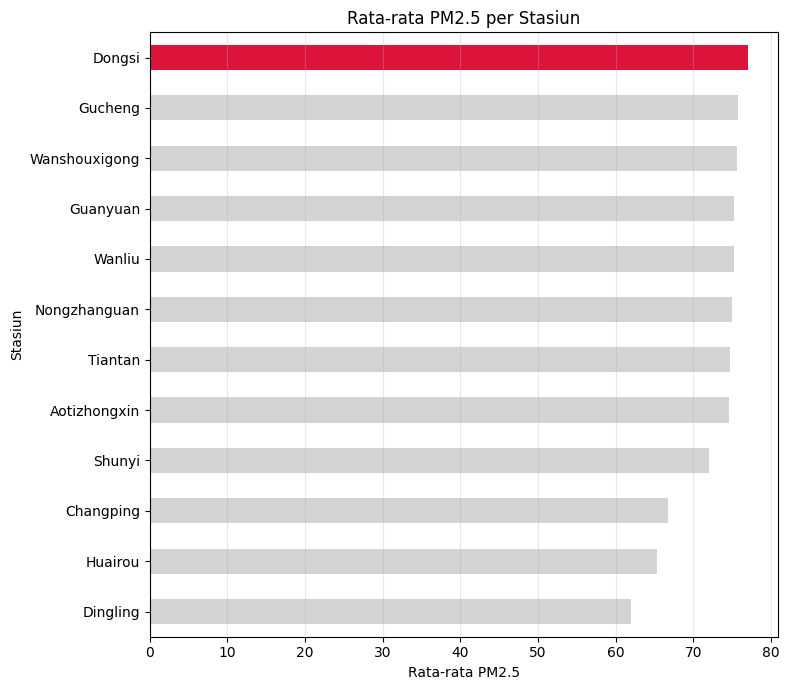

In [13]:
plt.figure(figsize=(8,7))

# highlight tertinggi merah, lainnya abu
colors = [
    'crimson' if value == station_pm25.max() else 'lightgray'
    for value in station_pm25
]

station_pm25.plot(
    kind='barh', # tipe bar plot horizontal
    color=colors
)

# untuk mengubah urutan menjadi descending dari atas kebawah
plt.gca().invert_yaxis()

plt.title('Rata-rata PM2.5 per Stasiun')
plt.xlabel('Rata-rata PM2.5')
plt.ylabel('Stasiun')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi ini, dapat terlihat jelas bahwasanya stasiun pemantauan kualitas udara di daerah `Dongsi` menunjukkan rata-rata tingkat PM2.5 paling tinggi diantara wilayah lainnya, hal ini dapat menunjukkan bagaimana keramaian aktivitas sekitar Dongsi yang berdampak langsung pada kualitas udara di tempat tersebut. Akan tetapi, stasiun dengan tingkat polusi lainnya seperti stasiun `Gucheng` dan sederajatnya menunjukkan aktivitas yang hampir tidak jauh berbeda dibandingkan dengan stasiun `Dongsi`. Hal ini menunjukkan kemungkinkan jarak yang dekat antara stasiun `Dongsi` dan juga stasiun `Gucheng` serta stasiun dengan tingkat polusi sederajat lainnya.

### 4.3 Analisis Lanjutan - Visualisasi Persebaran Stasiun Dengan Metode GeoSpatial Analysis

#### Tujuan

Untuk mengetahui bagaimana persebaran stasiun pemantauan dan bagaimana level PM2.5 nya. Dari data tersebut kita dapat menyimpulkan bagaimana pengaruh daerah dapat memicu peningkatan level PM2.5 yang menjadi salah satu faktor terbesar pengaruh buruk kualitas udara.

Selanjutnya saya akan mengambil titik koordinat dari tiap stasiun berdasarkan data yang tersedia di publik. Namun sebelum itu, saya akan menampilkan kembali lokasi-lokasi yang terdaftar sebagai bahan observasi kali ini.

In [14]:
all_stations = df['station'].unique() # hanya menampilkan stasiun secara unik

print(all_stations)

['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']


Selanjutnya saya mengumpulkan data koordinat dan dikumpul kedalam sebuah list bernama `station_coords` serta menentukan titik koordinat pertama map ditunjukkan.  

In [15]:
# Kumpulan data koordinat stasiun
station_coords = {
    'Aotizhongxin': [39.98, 116.39],
    'Changping': [40.22, 116.23],
    'Dingling': [40.29, 116.22],
    'Dongsi': [39.93, 116.42],
    'Guanyuan': [39.93, 116.34],
    'Gucheng': [39.90, 116.22],
    'Huairou': [40.32, 116.63],
    'Nongzhanguan': [39.93, 116.46],
    'Shunyi': [40.12, 116.65],
    'Tiantan': [39.89, 116.41],
    'Wanliu': [39.98, 116.30],
    'Wanshouxigong': [39.87, 116.36]
}

# titik koordinat awal (Beijing)
m = folium.Map(location=[39.9, 116.4], zoom_start=10, tiles='CartoDB positron')

Saya juga membuat segmentasi visual dengan membuat logika percabangan sederhana dalam warna marker.

In [16]:
def get_color(pm):
    if pm < 72:
        return '#2ECC71'   # Low
    elif pm < 76:
        return '#F1C40F'   # Moderate
    else:
        return '#E74C3C'   # High

Selanjutnya, memanggil setiap marker berbentuk bulat dan nama stasiunnya menggunakan perulangan.

In [17]:
for station, pm in station_pm25.items():
    if station in station_coords:
        lat, lon = station_coords[station] # mengambil titik koordinat stasiun

        # fungsi menambah marker
        folium.CircleMarker(
            location=[lat, lon],
            radius=9,
            popup=f'{station}: {pm:.2f}',
            tooltip=station,
            color=get_color(pm),
            fill=True,
            fill_color=get_color(pm),
            fill_opacity=0.8
        ).add_to(m)

        # fungsi menambah label / nama stasiun
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                icon_size=(150, 36),
                icon_anchor=(0, 0),
                html=f"""
                <div style="
                    font-size: 9px;
                    font-weight: bold;
                    color: black;
                    white-space: nowrap;
                    transform: translate(-15px, 12px);
                ">
                    {station}
                </div>
                """
            )
        ).add_to(m)

Langkah terakhir adalah menambahkan legend agar memudahkan pemahaman konteks mengenai level PM2.5 berdasarkan warna, dilanjutkan dengan pemanggilan peta sebagai output akhir.

In [18]:
# inject legend dengan triple quote agar dapat mengetik kode html
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
background-color: white;
padding: 10px;
border: 1px solid black;
font-size: 14px;
z-index: 9999;
">
<b>Tingkat PM2.5</b><br>
<span style="color:#2ECC71;">●</span> Rendah<br>
<span style="color:#F1C40F;">●</span> Sedang<br>
<span style="color:#E74C3C;">●</span> Tinggi
</div>
"""

# Menambah Judul dengan bantuan triple quote untuk menulis kode html
title_html = """
<div style="
position: fixed;
top: 10px;
left: 50%;
transform: translateX(-50%);
z-index: 9999;
background-color: white;
padding: 6px 12px;
border: 1px solid black;
font-size: 16px;
font-weight: bold;
">
Persebaran Stasiun Berdasarkan Letak Geografis
</div>
"""
# menambahkan judul ke map
m.get_root().html.add_child(folium.Element(title_html))
# menambahkan legend kedalam map
m.get_root().html.add_child(folium.Element(legend_html))

# pemanggilan peta
m

Dari visualisasi geospatial di atas dapat terlihat secara langsung bahwa area stasiun Dongsi berada di tengah perkotaan Beijing, dan hal ini selaras dengan kondisi stasiun tersebut yang memiliki tingkat PM2.5 tertinggi di antara stasiun lainnya. Peta ini juga menunjukkan bahwa stasiun-stasiun yang berada di sekitar Dongsi cenderung memiliki tingkat PM2.5 yang hampir serupa, yaitu berada pada kategori sedang hingga tinggi. Selain itu, peta ini juga mengindikasikan bahwa tingkat PM2.5 yang lebih rendah cenderung terjadi pada area yang berlokasi lebih jauh dari pusat perkotaan. Visualisasi ini membantu memperkuat pernyataan bahwa letak geografis stasiun dapat memengaruhi tingkat PM2.5 di wilayah tersebut.

## 5. Kesimpulan dan Rekomendasi

### 5.1 Kesimpulan

1. **PM2.5 menunjukkan pola musiman dengan kenaikan signifikan pada periode tertentu.**  
   Berdasarkan visualisasi tren rata-rata PM2.5 bulanan selama periode 2013–2017, terlihat bahwa tingkat PM2.5 mengalami naik turun yang cukup jelas sepanjang waktu dan cenderung meningkat secara pesat pada bulan-bulan tertentu seperti bulan baru setelah pergantian tahun. Pola ini mengindikasikan adanya pengaruh faktor musiman terhadap kualitas udara, seperti perubahan cuaca, suhu, atau aktivitas manusia pada periode tertentu dalam setahun.

2. **Beberapa stasiun memiliki tingkat polusi yang lebih tinggi dibandingkan dengan stasiun lainnya.**  
   Analisis rata-rata PM2.5 per stasiun menunjukkan bahwa stasiun Dongsi memiliki kandungan PM2.5 tertinggi dibandingkan stasiun lainnya, diikuti oleh beberapa stasiun di area sekitarnya. Temuan ini diperkuat oleh visualisasi geospasial yang menunjukkan bahwa stasiun-stasiun di wilayah pusat kota cenderung memiliki tingkat polusi lebih tinggi dibandingkan area pinggiran, sehingga mengindikasikan adanya pengaruh lokasi geografis terhadap tingkat polusi udara terjadi.

### 5.2 Rekomendasi

1. **Fokus mitigasi emisi pada stasiun dengan PM2.5 tertinggi.**  
   Area yang secara konsisten menunjukkan tingkat PM2.5 tertinggi, khususnya wilayah sekitar stasiun Dongsi dan area urban terdekat, dapat diprioritaskan sebagai target utama dalam kebijakan pengurangan emisi karena berpotensi menjadi hotspot polusi udara.

2. **Terapkan kebijakan pengurangan emisi pada musim polusi tinggi.** 
   Karena analisis tren bulanan menunjukkan adanya pola musiman pada peningkatan PM2.5 khususnya mendekati tahun baru, kebijakan mitigasi seperti pembatasan emisi kendaraan pribadi, pengawasan aktivitas industri, atau kampanye pengurangan polusi dapat difokuskan pada periode-periode dengan risiko polusi tertinggi terjadi.

3. **Lakukan pemantauan real-time untuk dapat memperingati masyarakat lebih dini.**  
   Berdasarkan hasil visualisasi tren bulanan, dapat disimpulkan bahwa tingkat polusi dapat berubah secara signifikan pada waktu tertentu, sistem pemantauan kualitas udara secara real-time dapat membantu memberikan peringatan dini kepada masyarakat agar dapat mengambil tindakan pencegahan terhadap paparan polusi udara berlebih.

## Tambahan: Menyimpan Dataset Akhir Untuk dipakai Pada Dashboard

In [19]:
df.to_csv('dashboard/main_data.csv', index=False)